# Gram Schmidt methods comparison
The scope of this notebook is to compare the different Gram-Schmidt (GS) methods on loss and runtime.

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [ ]:
# To make results replicable
# A random seed is not being used because getting the same results each time,
# for this experiemnt, may show misleading trends
# (e.g., classical and modified GS show different performance over run 
# and one may prevail on the other from times to times
# to have more consistent runs, a wrapper could be build 
# to run the experiment multiple times (e.g., 100 times)
# to get consistent results
# np.random.seed(123)

### Helper functions

In [2]:
def gram_schmidt_classical(A):
    n, m = A.shape
    Q = np.zeros((n, m))
    for j in range(m):
        u = A[:, j].copy()
        for k in range(j):
            u -= np.dot(u, Q[:, k]) * Q[:, k]
        Q[:, j] = u / np.linalg.norm(u)
    return Q

In [3]:
def gram_schmidt_modified(A):
    """Modified Gram-Schmidt."""
    n, m = A.shape
    Q = np.zeros((n, m))
    U = A.copy()
    for j in range(m):
        u = U[:, j]
        for k in range(j):
            u = u - np.dot(u, Q[:, k]) * Q[:, k]
        Q[:, j] = u / np.linalg.norm(u)
    return Q

In [4]:
def gram_schmidt_classical_reorth(A):
    """Classical GS with two passes of orthogonalization."""
    n, m = A.shape
    Q = np.zeros((n, m))
    for j in range(m):
        u = A[:, j].copy()
        for _ in range(2):
            for k in range(j):
                u -= np.dot(u, Q[:, k]) * Q[:, k]
        Q[:, j] = u / np.linalg.norm(u)
    return Q

In [5]:
def gram_schmidt_modified_reorth(A):
    """Modified GS with two passes of orthogonalization."""
    n, m = A.shape
    Q = np.zeros((n, m))
    U = A.copy()
    for j in range(m):
        u = U[:, j]
        for i in range(2):
            for k in range(j):
                u = u - np.dot(u, Q[:, k]) * Q[:, k]
        Q[:, j] = u / np.linalg.norm(u)
    return Q

In [6]:
def generate_matrices_with_condition_numbers(n=20, num_mats=10):
    """
    Generate a list of matrices with increasing condition numbers.
    Matrices are created via singular value manipulation.

    Args:
        n (int):
            Size of the square matrices (default: 20).
        num_mats (int):
            Number of matrices to generate (default: 10).

    Returns:
        list:
            A list of numpy arrays, each (n × n), with condition numbers
            increasing roughly exponentially.
    
    """

    matrices = []
    target_conds = np.logspace(0, 10, num_mats)  
    # from 10^0 = 1 to 10^10

    for cond in target_conds:
        # Create random orthogonal matrices U, V
        U, _ = np.linalg.qr(np.random.randn(n, n))
        V, _ = np.linalg.qr(np.random.randn(n, n))

        # Create singular values spanning the desired condition number
        s = np.linspace(1, 1/cond, n)

        # Construct A = U diag(s) V^T
        A = U @ np.diag(s) @ V.T
        matrices.append(A)

    return matrices

In [7]:
def orthogonality_loss(Q):
    """
    Return Frobenius norm of deviation from orthogonality.
    Frobenius norm is chosen for this exercise because easier 
    to compute than the Spectral (operator 2) norm.
    
    """
    
    m, n = Q.shape
    return np.linalg.norm(np.eye(n) - Q.T @ Q, ord="fro")

In [8]:
def reconstruction_loss(A, Q):
    """Relative reconstruction error ||A - QQ^T A||_F / ||A||_F."""
    A_hat = Q @ (Q.T @ A)
    return np.linalg.norm(A - A_hat, ord="fro") / np.linalg.norm(A, ord="fro")

In [9]:
def run_gs_multiple_times(gs_type="classical", n=20, num_mats=10):
    
    elapsed_times = []
    
    matrices = generate_matrices_with_condition_numbers(
        n, num_mats)

    if gs_type=="classical":
        func = gram_schmidt_classical
    elif gs_type=="modified":
        func = gram_schmidt_modified
    elif gs_type=="classical_reorth":
        func = gram_schmidt_classical_reorth
    elif gs_type=="modified_reorth":
        func = gram_schmidt_modified_reorth
    else:
        print(f"Invalid `gs_type` type: {gs_type}.")
        print("Insert 'classical', 'modified', 'classical_reorth', or 'modified_reorth'.")
        return

    Q_results = []
    for mat in matrices:
        start = time.perf_counter()
        Q = func(mat)
        end = time.perf_counter()
        time_diff = end - start
        Q_results.append(Q)
        elapsed_times.append(time_diff)
    
    return Q_results, elapsed_times

In [10]:
def compute_metrics(matrices, Q_list, loss_type="orth"):
    """
    Given original matrices A_i and Q_i from GS, return
    condition numbers and losses.
    
    """
    conds = []
    losses = []

    for A, Q in zip(matrices, Q_list):
        conds.append(np.linalg.cond(A))

        if loss_type == "orth":
            losses.append(orthogonality_loss(Q))
        elif loss_type == "recon":
            losses.append(reconstruction_loss(A, Q))
        else:
            raise ValueError("`loss_type` must be 'orth' or 'recon'.")

    return np.array(conds), np.array(losses)


In [11]:
def plot_cond_vs_loss(gs_type, loss_type, conds, losses, label="", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))

    ax.plot(np.log10(conds), losses, "o-", label=label)
    ax.set_xlabel("log10(condition number)")
    ax.set_ylabel("loss")
    ax.set_title(f"{gs_type}: log(cond) vs {loss_type} loss")
    ax.grid(True)

    if label:
        ax.legend()

    plt.show()

In [12]:
def runGS_and_plot(gs_type, n=20, num_mats=10, loss_type="orth"):
    matrices = generate_matrices_with_condition_numbers(n, num_mats)
    Q_list, elapsed_times = run_gs_multiple_times(gs_type, n=n, num_mats=num_mats)
    conds, losses = compute_metrics(matrices, Q_list, loss_type=loss_type)
    
    return conds, losses, elapsed_times

In [13]:
def plot_elapsed_times(conds, elapsed_times, total_time, gs_type):
    plt.figure(figsize=(6,4))
    plt.plot(conds, elapsed_times, "o-", color="red")
    
    plt.xlabel("Condition number (computed)")
    plt.ylabel("Elapsed time per matrix (s)")
    plt.xscale("log")  # since conds vary exponentially
    
    plt.title(f"{gs_type} — timing per matrix")
    plt.suptitle(f"Total time: {total_time:.6f} seconds")

    plt.grid(True)
    plt.show()

In [14]:
def plot_all_losses(gs_results, loss_type):
    """Plot loss curves for all GS methods in one figure."""
    plt.figure(figsize=(6,4))
    for gs_type, (conds, losses, _, _) in gs_results.items():
        plt.plot(np.log10(conds), losses, "o-", label=gs_type)

    plt.xlabel("log10(condition number)")
    plt.ylabel("loss")
    plt.title(f"All GS methods — log(cond) vs {loss_type} loss")
    plt.grid(True)
    plt.legend()
    plt.show()

In [15]:
def plot_all_times(gs_results):
    """Plot timing curves for all GS methods in one figure."""
    plt.figure(figsize=(6,4))
    for gs_type, (conds, _, elapsed_times, _) in gs_results.items():
        plt.plot(np.log10(conds), elapsed_times, "o-", label=gs_type)

    plt.xlabel("log10(condition number)")
    plt.ylabel("Elapsed time per matrix (s)")
    plt.title("All GS methods — timing per matrix")
    plt.grid(True)
    plt.legend()
    plt.show()

In [16]:
def runAllGSAndPlot(gs_types, n=20, num_mats=10, loss_type="orth", plot_combined=True):
    if not isinstance(gs_types, list):
        gs_types = [gs_types]

    gs_results = {}

    for gs in gs_types:
        conds, losses, elapsed_times = runGS_and_plot(gs, n=n, num_mats=num_mats, loss_type=loss_type)
        tot_elapsed_times = np.sum(elapsed_times)

        if not plot_combined:
            # existing behavior
            plot_cond_vs_loss(gs, loss_type, conds, losses, label=gs)
            plot_elapsed_times(conds, elapsed_times, tot_elapsed_times, gs)

        gs_results[gs] = (conds, losses, elapsed_times, tot_elapsed_times)

    # If combined mode, plot all curves together only after all results are collected
    if plot_combined:
        plot_all_losses(gs_results, loss_type)
        plot_all_times(gs_results)

    return gs_results

### Modelling

In [18]:
gs_methods_list = [
    "classical",
    "modified",
    "classical_reorth",
    "modified_reorth"
]

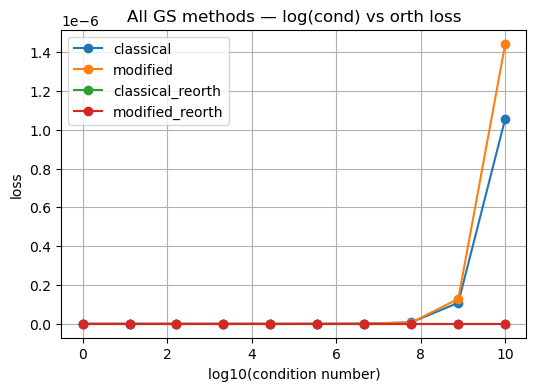

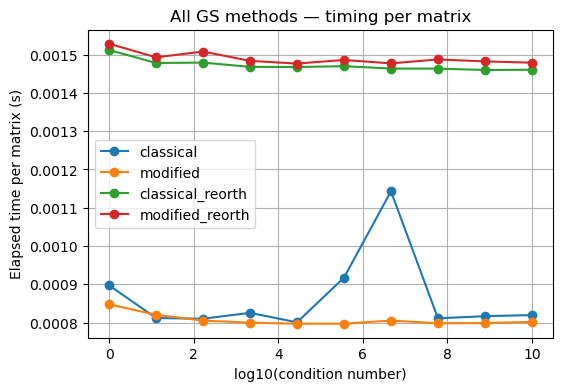

In [19]:
gs_results = runAllGSAndPlot(
    gs_methods_list, n=20, num_mats=10, loss_type="orth", plot_combined=True)

As expected, the reorthogonized methods take significantly more time, around `1.5` more, although, unexpectedly, the time taken is not increasing with the condition number, but the opposite is happening. It is also worth noticing that the loss blows up in size slightly before `log10(condition_number)=8`, showing how the matrix becomes poorly conditioned and numerical instability blows up after a phase transition provoked by the condition number surpassing a certain threshold.

The reorthogonalized GS functions are expectedly to produce a much smaller loss compared to their less safe counterparts, and zooming in will allow for a better comparison.

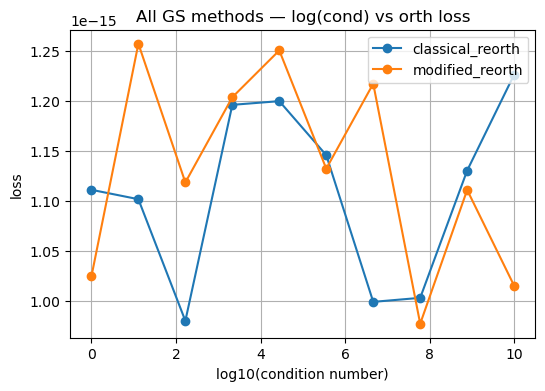

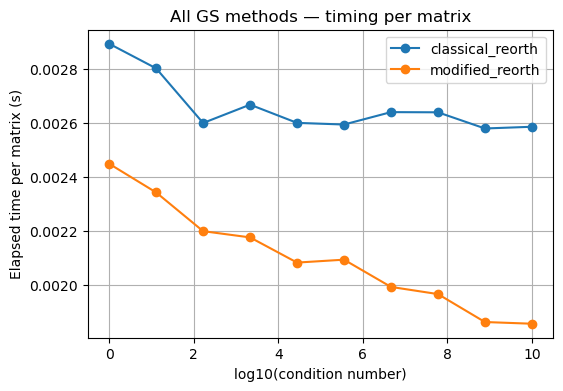

In [23]:
gs_methods_list_reduced = [
    "classical_reorth",
    "modified_reorth"
]

gs_results_zoomed = runAllGSAndPlot(
    gs_methods_list_reduced, n=20, num_mats=10, loss_type="orth", plot_combined=True)

The two methods exhibit similar results across different run, but the modified version show less variance overall in the time taken.